In [ ]:
from pathlib import Path
import statistics
import time
from itertools import cycle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from host.runtime import Runtime
from wasmtime import Store
from wasmtime.component import Instance


#hee heeeee

In [36]:
PROJECT_ROOT = Path.cwd()

C_WASM = (
    PROJECT_ROOT /
    "plugins" /
    "build" /
    "example_c.wasm"
)

RUST_WASM = (
    PROJECT_ROOT /
    "plugins" /
    "build" /
    "example_rust.wasm"
)

NATIVE_CSV = (
    PROJECT_ROOT /
    "native_runners" /
    "native.csv"
)

print("C wasm exists:", C_WASM.exists())
print("Rust wasm exists:", RUST_WASM.exists())
print("Native CSV exists:", NATIVE_CSV.exists())

C wasm exists: True
Rust wasm exists: True
Native CSV exists: True


In [37]:
HEAVY_WARMUP = 200
HEAVY_RUNS = 2500
LOAD_REPEATS = 20
SUMARRAY_LEN = 80
INPUT_ROWS = 2500

BACKENDS = {
    "C": C_WASM,
    "Rust": RUST_WASM,
}

WORKLOADS = [
    "sumarray",
    "mul",
    "sumab",
    "greet",
    "noReturn",
    "doubleArray"
]

## Input Data

In [38]:
sumarray_inputs_df = pd.DataFrame({
    "numbers": [
        list(range(i % 5, i % 5 + SUMARRAY_LEN))
        for i in range(INPUT_ROWS)
    ]
})

mul_inputs_df = pd.DataFrame({
    "numbers": [
        list(((i + 1) % 7) + j
        for j in range(SUMARRAY_LEN))
        for i in range(INPUT_ROWS)
    ]
})

sumab_inputs_df = pd.DataFrame({
    "value_a": [
        i % 101
        for i in range(INPUT_ROWS)
    ],

    "value_b": [
        (i * 7) % 97
        for i in range(INPUT_ROWS)
    ],
})

greet_inputs_df = pd.DataFrame({
    "name": [
        f"user_{i:04d}"
        for i in range(INPUT_ROWS)
    ]
})

no_return_inputs_df = pd.DataFrame({
    "dummy": [
        0
        for _ in range(INPUT_ROWS)
    ]
})

double_inputs_df = pd.DataFrame({
    "numbers": [
        list(range(i % 5, i % 5 + SUMARRAY_LEN))
        for i in range(INPUT_ROWS)
    ]
})

INPUT_FRAMES = {
    "sumarray": sumarray_inputs_df,
    "mul": mul_inputs_df,
    "sumab": sumab_inputs_df,
    "greet": greet_inputs_df,
    "noReturn": no_return_inputs_df,
    "doubleArray": double_inputs_df,
}

## Metrics Probe

In [39]:
class MetricsProbe:
    def __init__(self, runtime: Runtime):
        self.runtime = runtime
        self.encode_ns = 0
        self.decode_ns = 0
        self.host_to_wasm_bytes = 0
        self.wasm_to_host_bytes = 0
        self._orig_encode = runtime._typesys.encode
        self._orig_decode = runtime._typesys.decode
        self._orig_write_bytes = runtime._mem_mgr.write_bytes
        self._orig_read_with_length_prefix = runtime._mem_mgr.read_with_length_prefix
        self._install()

    def _install(self):
        def wrapped_encode(data):
            start = time.perf_counter_ns()
            out = self._orig_encode(data)
            self.encode_ns += (time.perf_counter_ns()- start)
            return out

        def wrapped_decode(data):
            start = time.perf_counter_ns()
            out = self._orig_decode(data)
            self.decode_ns += (time.perf_counter_ns() - start)
            return out

        def wrapped_write_bytes(store: Store, instance: Instance, data_bytes: bytes):
            self.host_to_wasm_bytes += len(data_bytes)
            return self._orig_write_bytes(store, instance, data_bytes)

        def wrapped_read_with_length_prefix(store: Store,instance: Instance, ptr: int):
            raw = self._orig_read_with_length_prefix(store, instance, ptr)
            if raw is not None:
                self.wasm_to_host_bytes += len(raw) + 4

            return raw

        self.runtime._typesys.encode = wrapped_encode
        self.runtime._typesys.decode = wrapped_decode
        self.runtime._mem_mgr.write_bytes = wrapped_write_bytes
        self.runtime._mem_mgr.read_with_length_prefix = wrapped_read_with_length_prefix

## Helpers

In [40]:
def percentile(values, p):
    ordered = sorted(values)
    if not ordered:
        return 0.0
    
    index = round((p / 100) * (len(ordered) - 1))
    return ordered[index]

In [41]:
def call_wasm(plugin, workload, row):
    if workload == "sumarray":
        return plugin.sumarray(row.numbers)

    if workload == "mul":
        return plugin.mul(row.numbers)

    if workload == "sumab":
        return plugin.sumab(int(row.value_a), int(row.value_b))

    if workload == "greet":
        return plugin.greet(row.name)

    if workload == "noReturn":
        return plugin.noReturn()

    if workload == "doubleArray":
        return plugin.doubleArray(row.numbers)

## WASM Benchmark Runner

In [42]:
def benchmark_backend(backend_name, module_path, input_frames):
    runtime = Runtime()
    load_samples_ms = []
    for _ in tqdm(range(LOAD_REPEATS), desc=f"{backend_name} load", leave=False):
        start = time.perf_counter_ns()
        plugin = runtime.load_module(str(module_path))
        load_samples_ms.append((time.perf_counter_ns() - start) / 1_000_000)
        runtime.unload_module(plugin._ctx)

    plugin = runtime.load_module(str(module_path))
    probe = MetricsProbe(runtime)
    rows = []

    for workload, frame in input_frames.items():
        warm_rows = list(frame.itertuples(index=False))[:HEAVY_WARMUP]

        for row in warm_rows:
            call_wasm(plugin, workload, row)

        probe.encode_ns = 0
        probe.decode_ns = 0
        probe.host_to_wasm_bytes = 0
        probe.wasm_to_host_bytes = 0
        latencies = []
        cyc = cycle(frame.itertuples(index=False))

        for _ in tqdm(range(HEAVY_RUNS), desc=f"{backend_name} {workload}", leave=False):
            row = next(cyc)
            start = time.perf_counter_ns()
            call_wasm(plugin, workload, row)
            latencies.append((time.perf_counter_ns() - start) / 1_000_000)

        total_call_ns = sum(latencies) * 1_000_000
        serialization_ns = probe.encode_ns + probe.decode_ns

        rows.append({
            "backend": backend_name,
            "workload": workload,
            "load_avg_ms": statistics.fmean(load_samples_ms),
            "load_p50_ms": percentile(load_samples_ms, 50),
            "load_p95_ms": percentile( load_samples_ms, 95),
            "latency_avg_ms": statistics.fmean(latencies),
            "latency_p50_ms": percentile(latencies,50),
            "latency_p95_ms": percentile(latencies, 95),
            "serialization_ms": serialization_ns / 1_000_000,
            "serialization_overhead_pct": (serialization_ns / total_call_ns * 100.0) if total_call_ns else 0.0,
            "host_to_wasm_bytes": probe.host_to_wasm_bytes,
            "wasm_to_host_bytes": probe.wasm_to_host_bytes,
            "throughput_ops_per_sec": (HEAVY_RUNS / (sum(latencies) / 1000.0))
        })

    runtime.unload_module(plugin._ctx)
    return pd.DataFrame(rows)

## Run WASM Benchmarks

In [43]:
wasm_c_df = benchmark_backend("WASM C", BACKENDS["C"], INPUT_FRAMES)
wasm_rust_df = benchmark_backend("WASM Rust", BACKENDS["Rust"], INPUT_FRAMES)
wasm_df = pd.concat([wasm_c_df, wasm_rust_df])

## Load Native Metrics

In [44]:
native_df = pd.read_csv(NATIVE_CSV)
native_df

,backend,workload,latency_avg_ms,latency_p95_ms,throughput_ops_per_sec
0,Native C,sumarray,0.000100,0.000092,9997325.66
1,Native C,mul,0.000105,0.000094,9553705.83
2,Native C,sumab,0.000102,0.000076,9837377.24
3,Native C,greet,0.000116,0.000119,8596599.28
4,Native C,noReturn,0.000047,0.000048,21277304.12
5,Native C,doubleArray,0.000279,0.001931,3586311.27
6,Native Rust,sumarray,0.000051,0.000053,19519355.39
7,Native Rust,mul,0.000056,0.000053,17811469.16
8,Native Rust,sumab,0.000051,0.000053,19485276.92
9,Native Rust,greet,0.000298,0.000294,3358968.98


## Plot Helper

In [45]:
def add_labels(ax):
    for container in ax.containers:
        ax.bar_label(container, fmt="%.6f", padding=3,fontsize=8)

In [46]:
def metric_direction(metric):
    higher_better = ["throughput_ops_per_sec"]
    if metric in higher_better:
        return "Higher is Better"
    return "Lower is Better"

## Native vs WASM Metrics

In [47]:
native_compare_metrics = [
    "latency_avg_ms",
    "latency_p95_ms",
    "throughput_ops_per_sec"
]

## Native vs WASM Plots

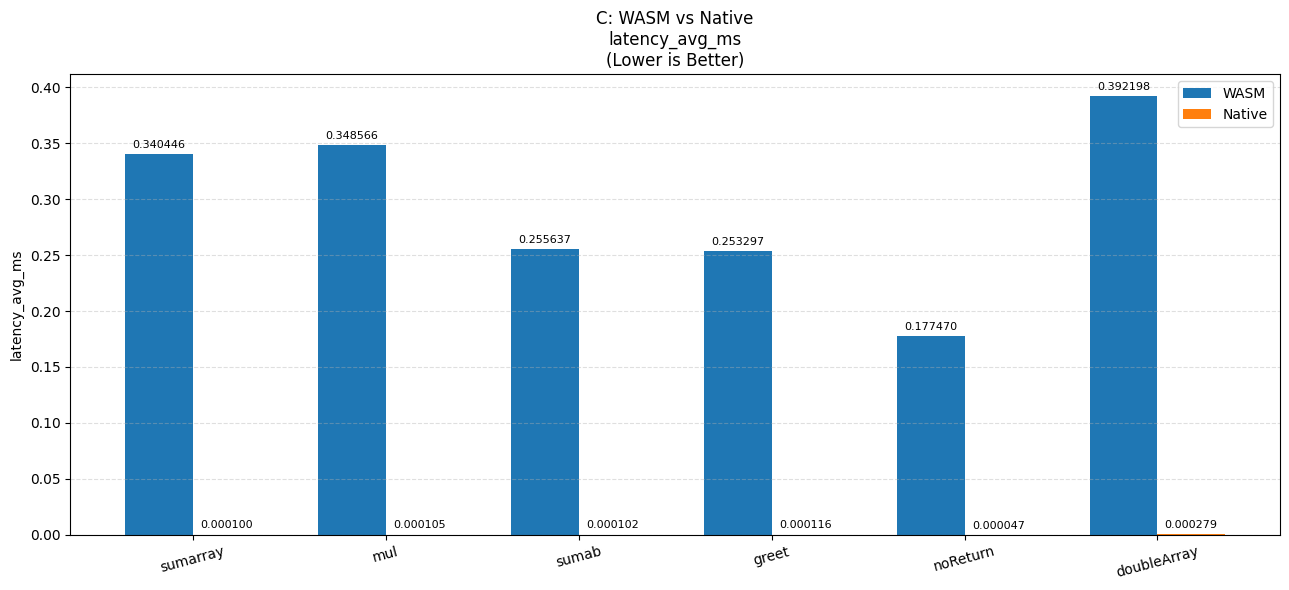

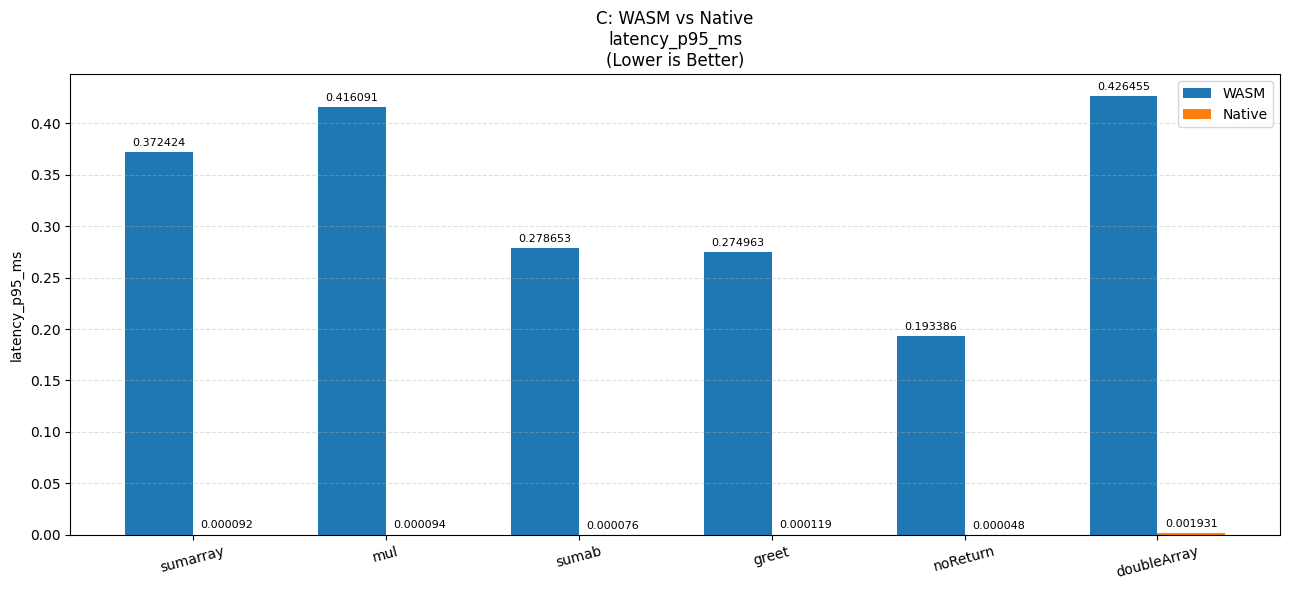

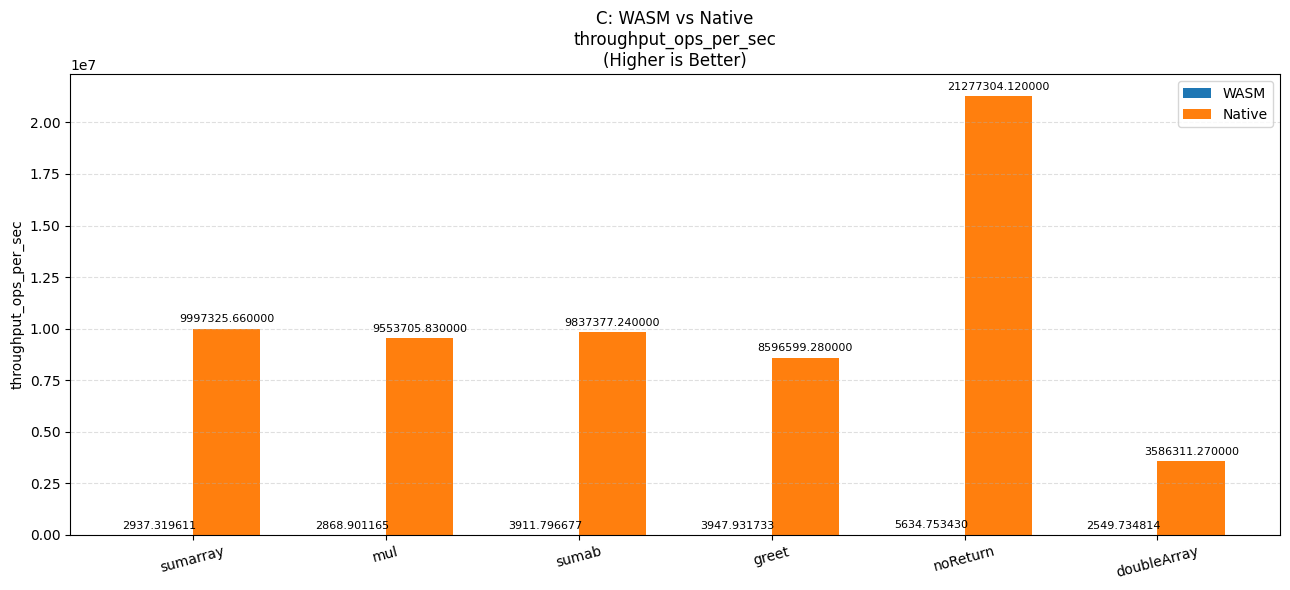

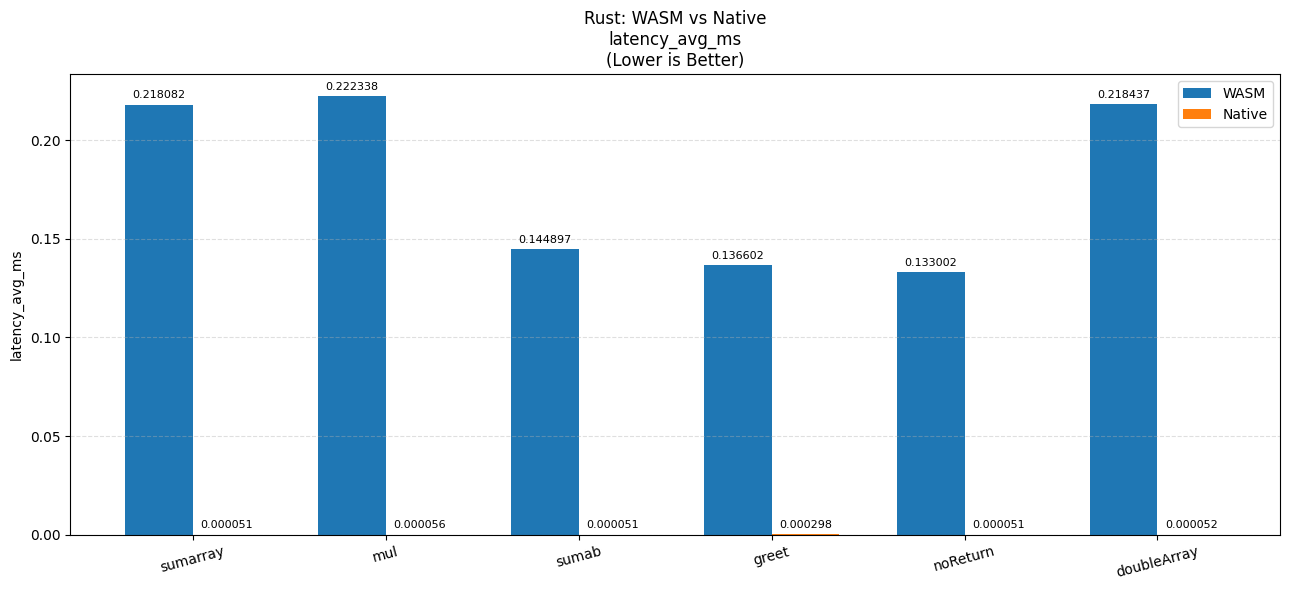

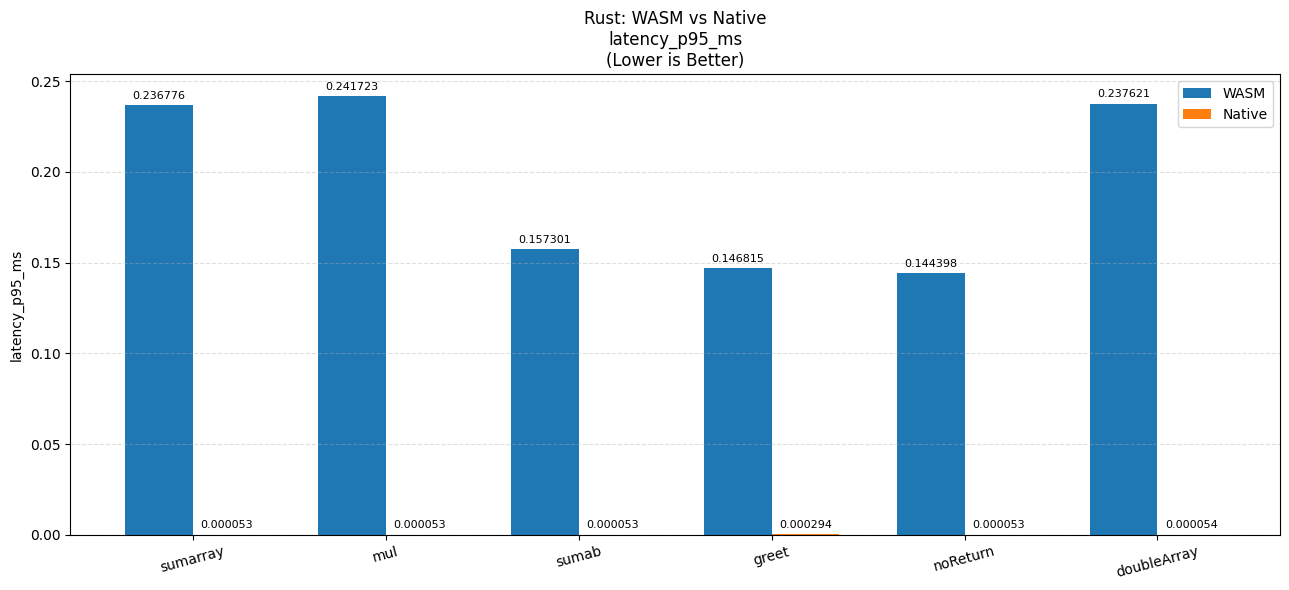

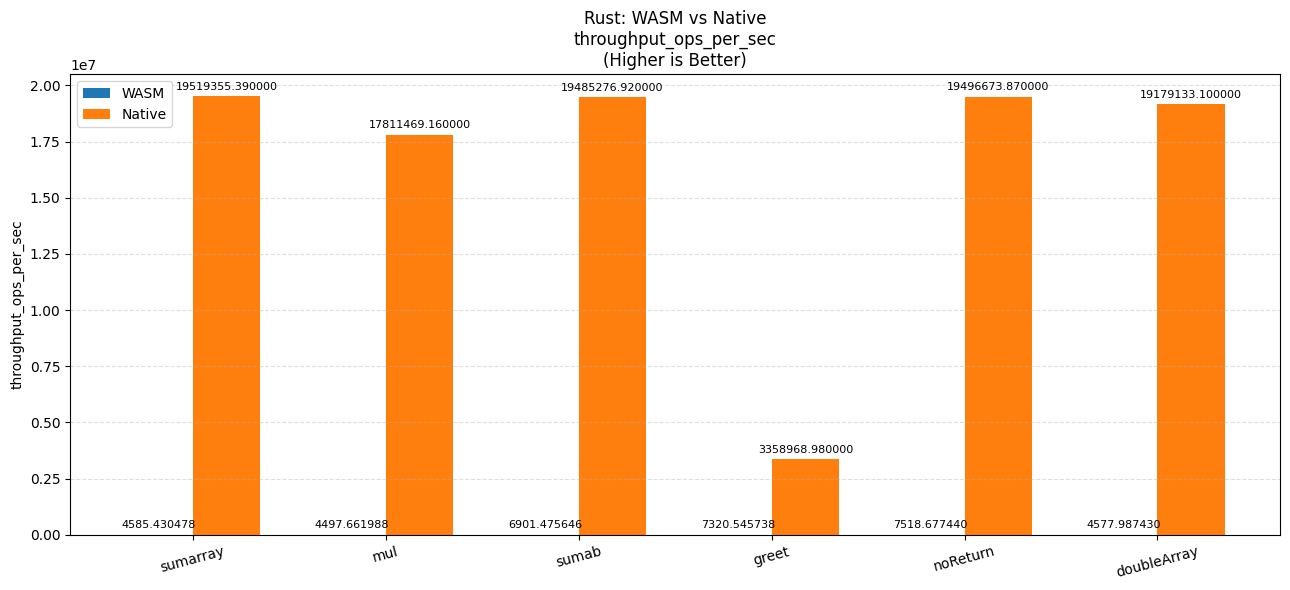

In [48]:
for language in ["C", "Rust"]:
    wasm_backend = (f"WASM {language}")
    native_backend = (f"Native {language}")
    wasm_subset = wasm_df[wasm_df["backend"] == wasm_backend]
    native_subset = native_df[native_df["backend"] == native_backend]
    merged = pd.merge(wasm_subset, native_subset, on="workload", suffixes=("_wasm", "_native"))

    for metric in native_compare_metrics:
        fig, ax = plt.subplots(figsize=(13, 6))
        x = np.arange(len(merged))
        width = 0.35
        wasm_vals = (merged[f"{metric}_wasm"])
        native_vals = (merged[f"{metric}_native"])
        ax.bar(x - width / 2, wasm_vals, width, label="WASM")
        ax.bar(x + width / 2, native_vals, width, label="Native")
        ax.set_xticks(x)
        ax.set_xticklabels(merged["workload"], rotation=15)
        ax.set_ylabel(metric)
        ax.set_title(
            f"{language}: WASM vs Native\n"
            f"{metric}\n"
            f"({metric_direction(metric)})"
        )
        ax.grid(axis="y", linestyle="--", alpha=0.4)
        ax.legend()
        add_labels(ax)
        plt.tight_layout()
        plt.show()

## WASM-only Metrics

In [49]:
wasm_only_metrics = [
    "load_avg_ms",
    "load_p50_ms",
    "load_p95_ms",
    "latency_p50_ms",
    "serialization_ms",
    "serialization_overhead_pct",
    "host_to_wasm_bytes",
    "wasm_to_host_bytes"
]

## WASM C vs WASM Rust Plots

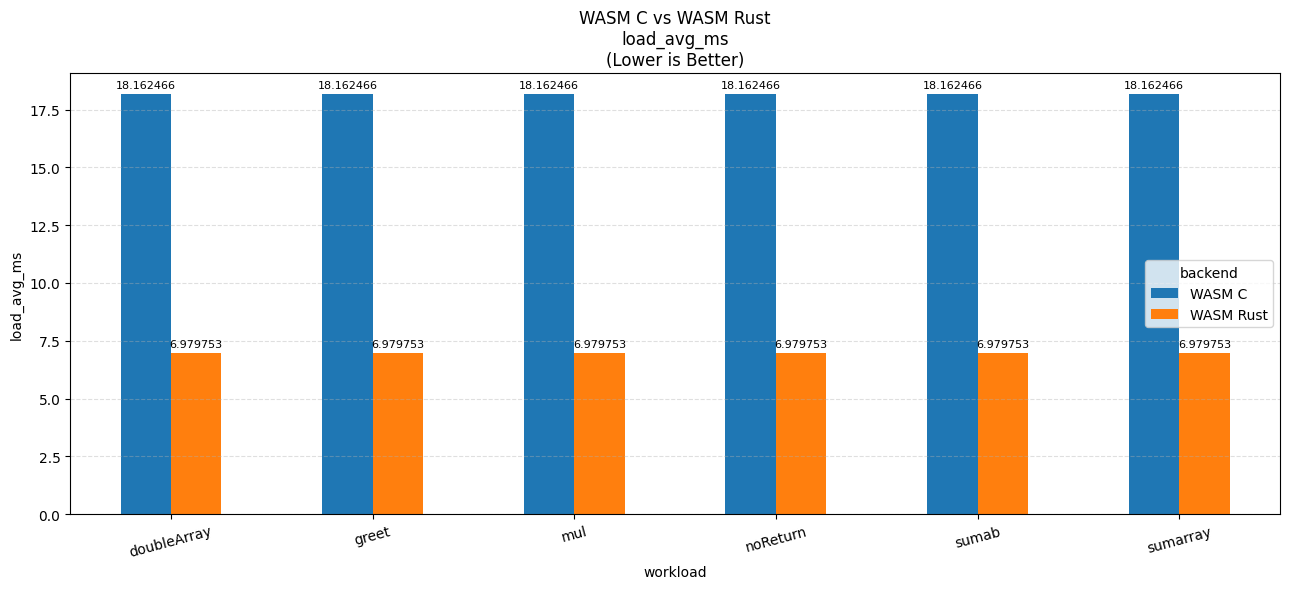

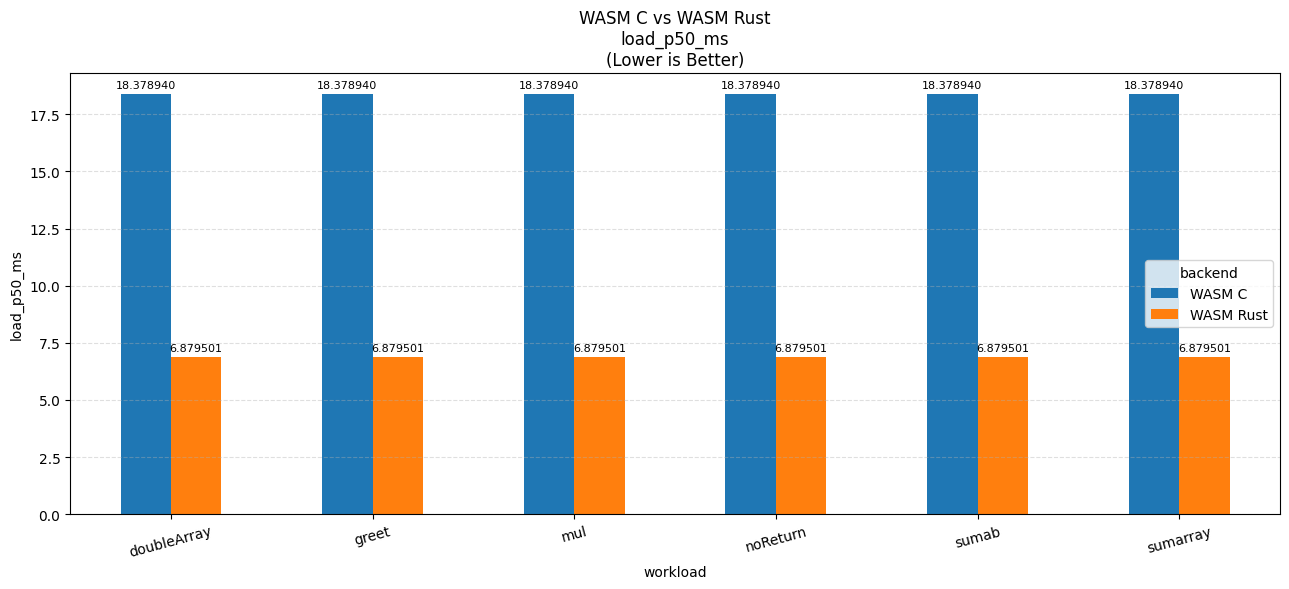

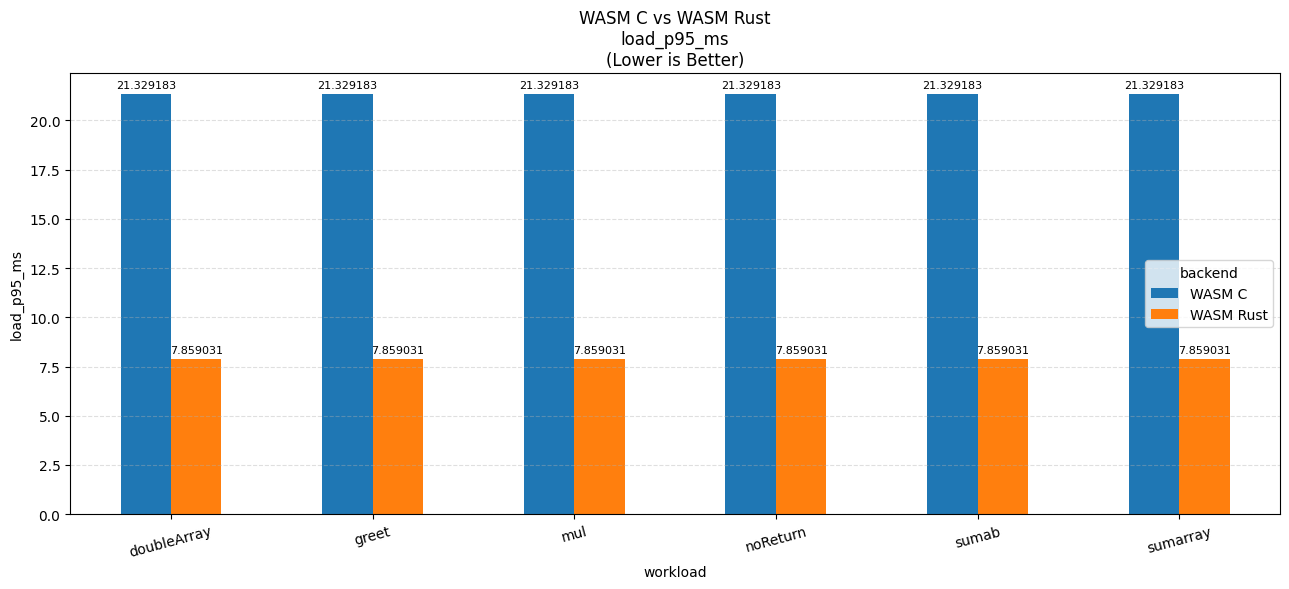

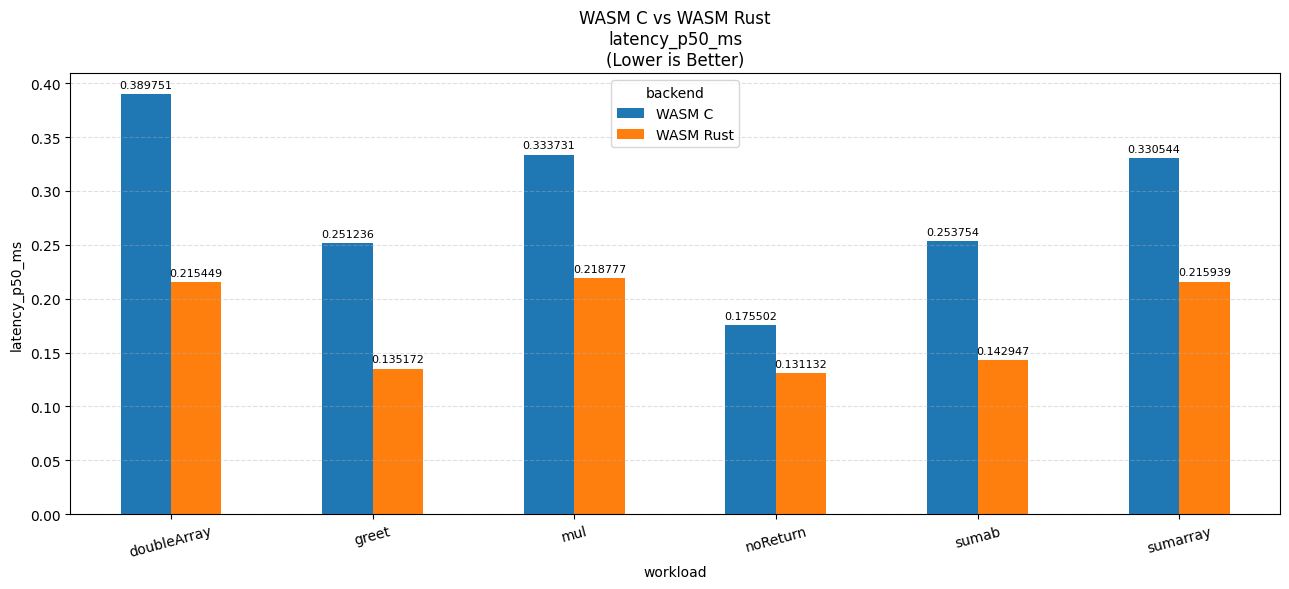

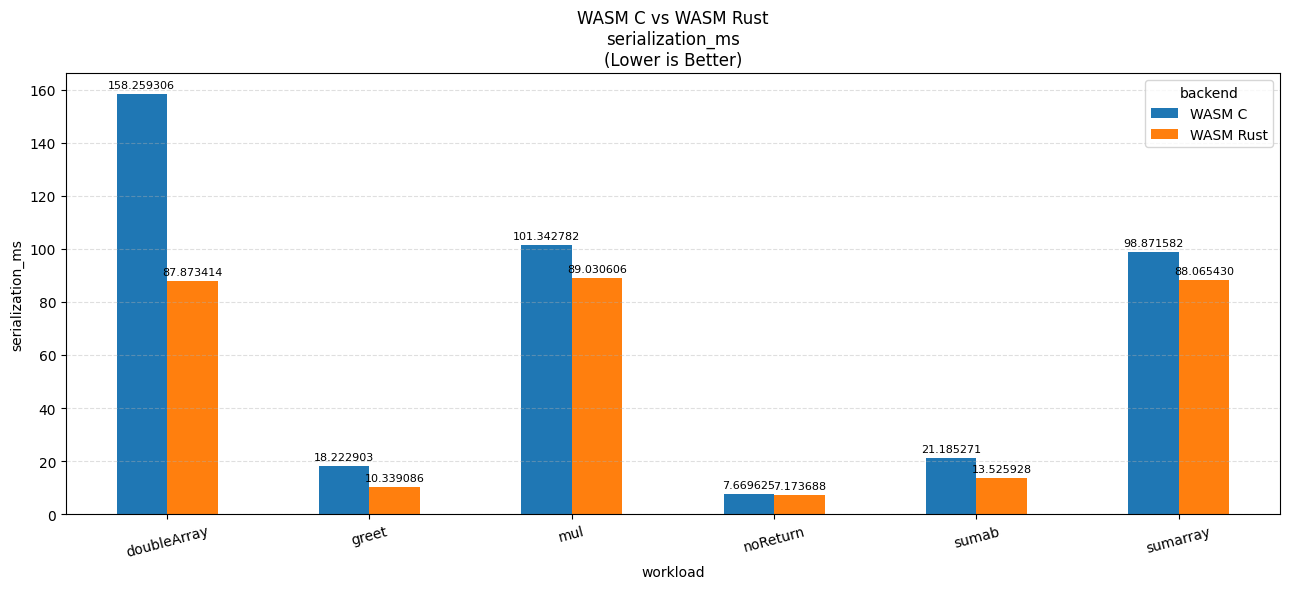

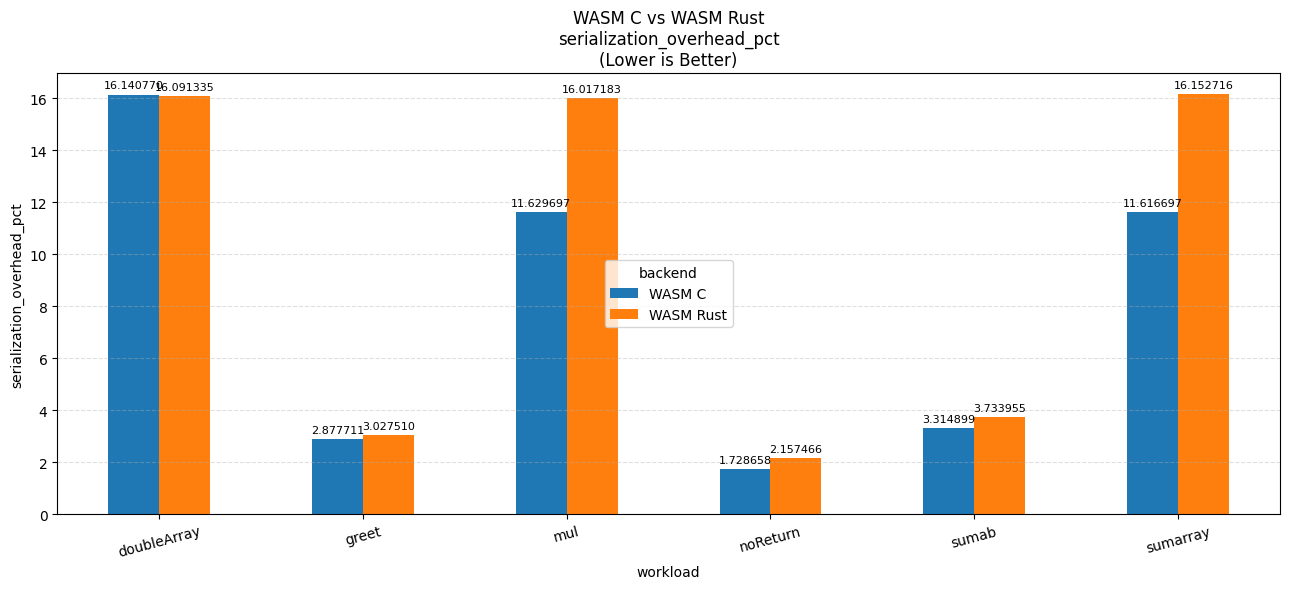

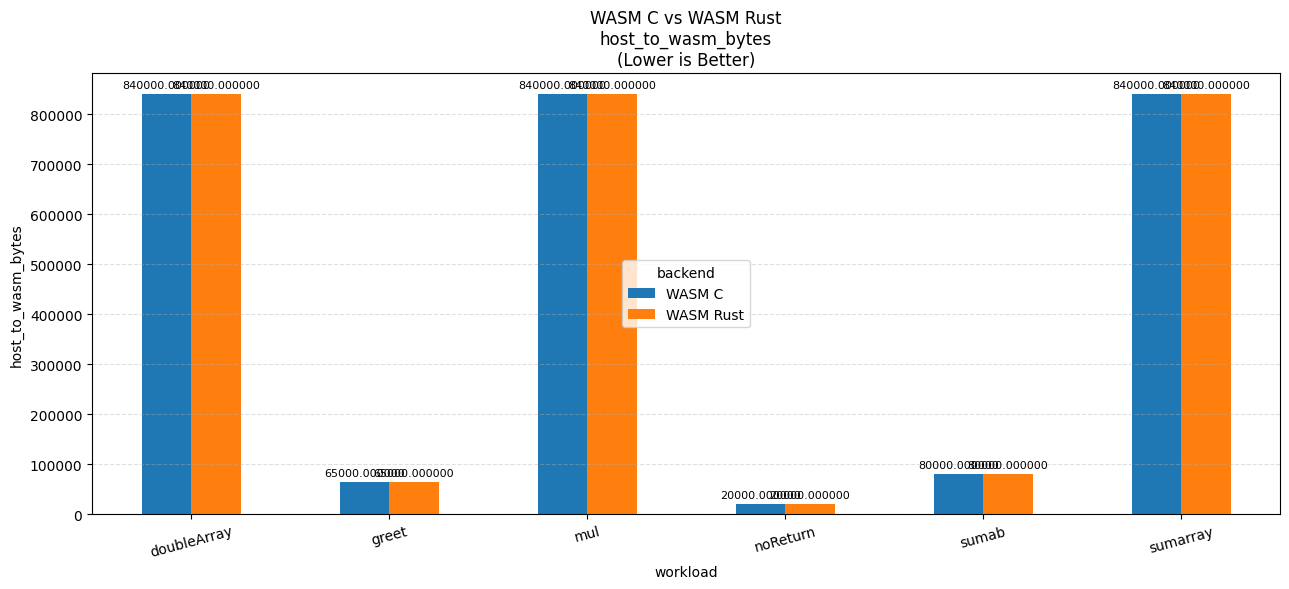

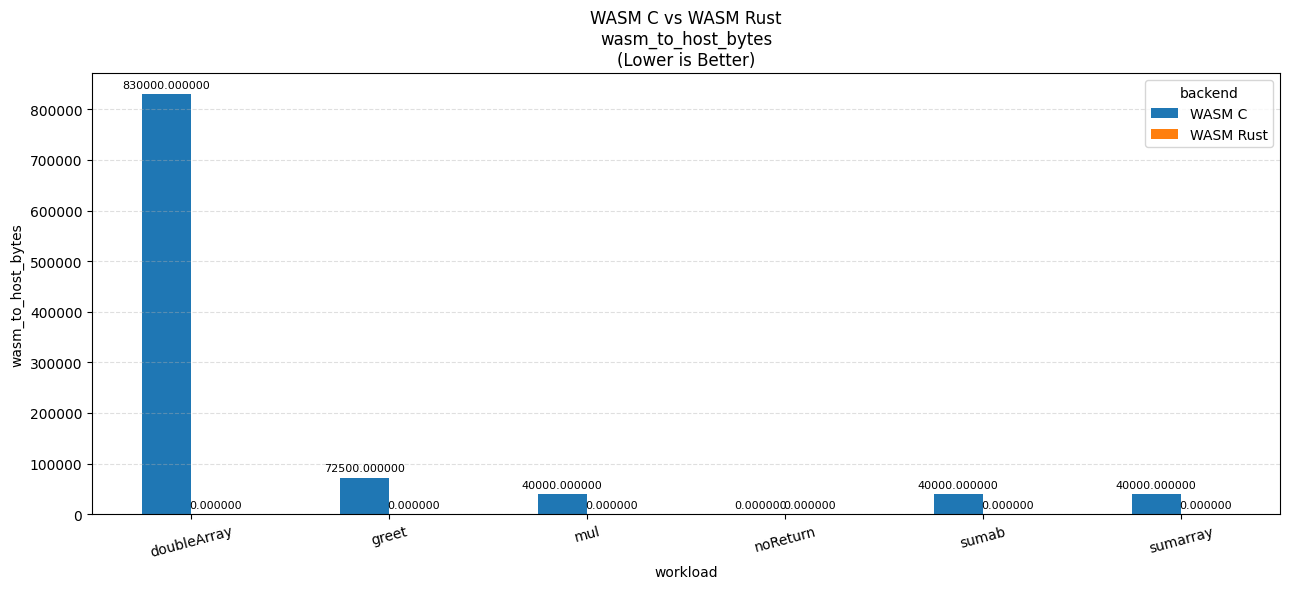

In [50]:
for metric in wasm_only_metrics:
    pivot = wasm_df.pivot(index="workload", columns="backend", values=metric)
    fig, ax = plt.subplots(figsize=(13, 6))
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(
        f"WASM C vs WASM Rust\n"
        f"{metric}\n"
        f"({metric_direction(metric)})"
    )
    ax.set_ylabel(metric)
    ax.set_xticklabels(pivot.index, rotation=15)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    add_labels(ax)
    plt.tight_layout()
    plt.show()